# 11.3. 섭동론

In [1]:
import numpy as np

N = 60

a = np.diag(np.sqrt(np.arange(1, N)), 1)
X = (a + a.T) / np.sqrt(2)
E0 = np.arange(N) + 0.5

X3 = X @ X @ X
X4 = X3 @ X

print(f"<0|x^3|0> = {X3[0, 0]:.6f}")
print(f"<0|x^4|0> = {X4[0, 0]:.6f}  (이론값 3/4)")

<0|x^3|0> = 0.000000
<0|x^4|0> = 0.750000  (이론값 3/4)


In [2]:
def corrections(c, d):
    Hp = c / 6 * X3 + d / 24 * X4

    E1 = Hp[0, 0]
    E2 = sum(Hp[0, m] ** 2 / (E0[0] - E0[m]) for m in range(1, N))
    return E1, E2


c, d = -0.1, 0.1
E1, E2 = corrections(c, d)

print(f"0차 (조화)   : {0.5:.8f}")
print(f"1차 보정     : {E1:+.8f}   (이론값 d/32 = {d/32:.8f})")
print(f"2차 보정     : {E2:+.8f}")
print(f"2차까지 합계 : {0.5 + E1 + E2:.8f}")

0차 (조화)   : 0.50000000
1차 보정     : +0.00312500   (이론값 d/32 = 0.00312500)
2차 보정     : -0.00042752
2차까지 합계 : 0.50269748


In [3]:
def solve_1d(V, x, mass):
    N = len(x)
    dx = x[1] - x[0]
    D2 = (-2 * np.eye(N) + np.eye(N, k=1) + np.eye(N, k=-1)) / dx**2
    H = -1 / (2 * mass) * D2 + np.diag(V)
    E, _ = np.linalg.eigh(H)

    return E


x = np.linspace(-5, 5, 1000)
V = 0.5 * x**2 + c / 6 * x**3 + d / 24 * x**4
E_exact = solve_1d(V, x, 1.0)[0]

print(f"{'보정 없이'} {0.5:.8f}   오차 {0.5 - E_exact:+.2e}")
print(f"{'1차 보정'} {0.5 + E1:.8f}   오차 {0.5 + E1 - E_exact:+.2e}")
print(f"{'2차 보정'} {0.5 + E1 + E2:.8f}   오차 {0.5 + E1 + E2 - E_exact:+.2e}")
print(f"{'정확한 값'} {E_exact:.8f}")

보정 없이 0.50000000   오차 -2.72e-03
1차 보정 0.50312500   오차 +4.07e-04
2차 보정 0.50269748   오차 -2.04e-05
정확한 값 0.50271789


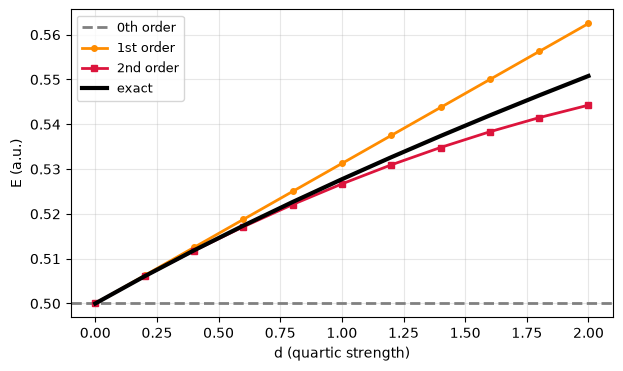

d = 0.10: 1차 0.50313, 2차 0.50308, 정확 0.50308
d = 0.50: 1차 0.51562, 2차 0.51449, 정확 0.51464
d = 1.00: 1차 0.53125, 2차 0.52669, 정확 0.52773
d = 2.00: 1차 0.56250, 2차 0.54427, 정확 0.55079


In [4]:
import matplotlib.pyplot as plt

ds = np.linspace(0, 2, 11)
e1, e2, ex = [], [], []

for d in ds:
    E1, E2 = corrections(0, d)
    e1.append(0.5 + E1)
    e2.append(0.5 + E1 + E2)
    V = 0.5 * x**2 + d / 24 * x**4
    ex.append(solve_1d(V, x, 1.0)[0])

fig, ax = plt.subplots(figsize=(7, 4))
ax.axhline(0.5, ls="--", lw=2, color="gray", label="0th order")
ax.plot(ds, e1, "o-", lw=2, ms=4, color="darkorange", label="1st order")
ax.plot(ds, e2, "s-", lw=2, ms=4, color="crimson", label="2nd order")
ax.plot(ds, ex, lw=3, color="black", label="exact")
ax.set_xlabel("d (quartic strength)")
ax.set_ylabel("E (a.u.)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.show()

for d in [0.1, 0.5, 1.0, 2.0]:
    E1, E2 = corrections(0, d)
    V = 0.5 * x**2 + d / 24 * x**4
    exv = solve_1d(V, x, 1.0)[0]
    print(f"d = {d:4.2f}: 1차 {0.5 + E1:.5f}, 2차 {0.5 + E1 + E2:.5f}, 정확 {exv:.5f}")